# Homework 4

## Consegna

 ### 1. Compressione di immagini

Caricare e visualizzare un’immagine (diversa
dal cameraman) in scala di grigio con matrice associata A di dimensione $mxn$. Fissati alcuni valori di $p$:


Inclusione librerie

Immagine dimensioni: 1212x800
Problema creato con Noise Level: 10.0%
Avvio ricostruzione Naive CGLS...
Ricostruzione completata. Errore Relativo: 1.4115


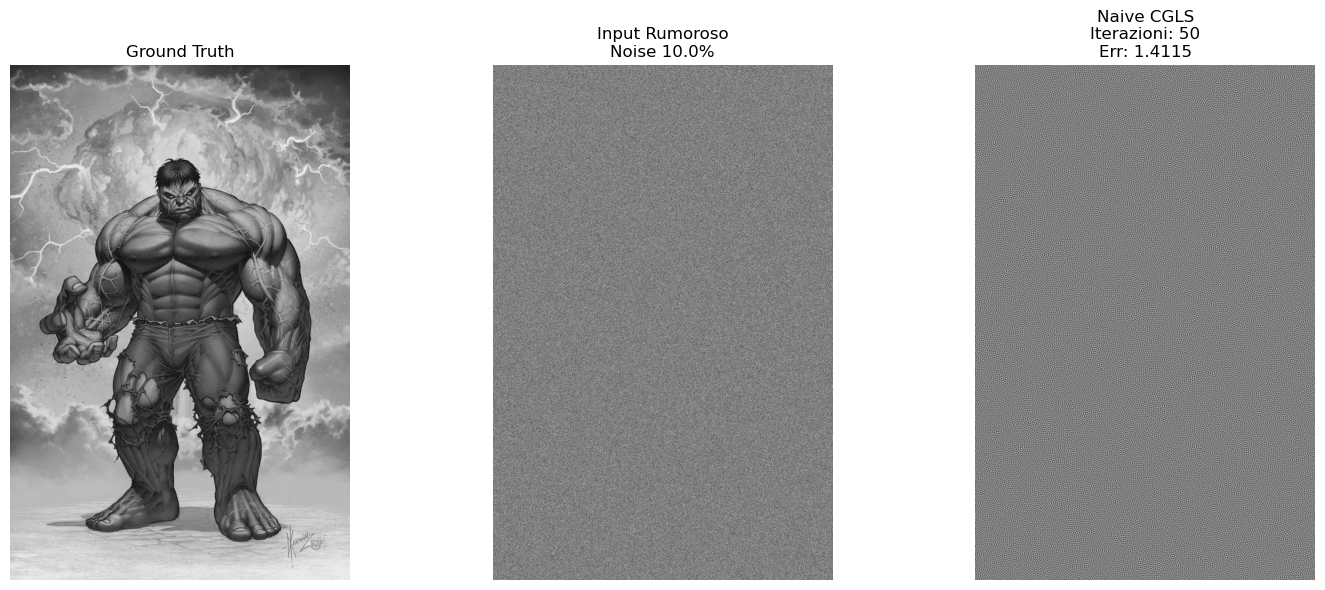

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.util import img_as_float

# Importazione moduli
try:
    from ProblemiInversi import operators, solvers, utilities
except ImportError:
    import operators, solvers, utilities

# =============================================================================
# 1. PREPARAZIONE DATI
# =============================================================================

# Caricamento Immagine
filename = 'hulk.bmp'
try:
    image_source = io.imread(filename)
    if image_source.ndim == 3:
        x_true = color.rgb2gray(image_source)
    else:
        x_true = image_source
    if x_true.max() > 1.0:
        x_true = x_true / 255.0
except FileNotFoundError:
    print(f"Errore: File {filename} non trovato. Uso immagine dummy.")
    x_true = np.zeros((100, 100)); x_true[20:80, 20:80] = 1.0 

m, n = x_true.shape
print(f"Immagine dimensioni: {m}x{n}")

# Creazione Operatore Blur
sigma = 2.0
k_size = 15
kernel = utilities.gaussian2d_kernel(k_size, sigma)
A = operators.ConvolutionOperator(kernel)

# Creazione Dati Rumorosi
noise_level = 0.1 # 10% di rumore
b_clean = A(x_true)
b_noisy = utilities.gaussian_noise(b_clean, noise_level)

print(f"Problema creato con Noise Level: {noise_level*100}%")

# =============================================================================
# 2. CODICE CGLS (NAIVE)
# =============================================================================
print("Avvio ricostruzione Naive CGLS...")

# Inizializzazione Solver
# Senza passare L e lambda, CGLS risolve il problema ai minimi quadrati standard: min ||Ax - y||^2
cgls_solver = solvers.CGLS(A)

# Parametri
kmax = 50   # Numero di iterazioni (Attenzione alla semiconvergenza!)
x0 = np.zeros_like(b_noisy) # Partenza da zero

# Soluzione
# Nota: La classe CGLS in solvers.py restituisce solo la soluzione x
x_cgls = cgls_solver.solve(b_noisy, x0, kmax=kmax)

# Calcolo errore
err_cgls = utilities.rel_err(x_cgls, x_true)
print(f"Ricostruzione completata. Errore Relativo: {err_cgls:.4f}")

# =============================================================================
# 3. VISUALIZZAZIONE
# =============================================================================
plt.figure(figsize=(15, 6))

# Ground Truth
plt.subplot(1, 3, 1)
plt.imshow(x_true, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

# Dati Rumorosi
plt.subplot(1, 3, 2)
plt.imshow(b_noisy, cmap='gray')
plt.title(f"Input Rumoroso\nNoise {noise_level*100}%")
plt.axis('off')

# Risultato CGLS
plt.subplot(1, 3, 3)
plt.imshow(x_cgls, cmap='gray')
plt.title(f"Naive CGLS\nIterazioni: {kmax}\nErr: {err_cgls:.4f}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Parametri richiesti dal PDF
psf_sigmas = [2.0, 4.0]      # Due diversi valori per la PSF
noise_levels = [0.1, 0.01]  # Livelli di rumore (es. 10% e 1%)

# Loop principale
for sigma in psf_sigmas:
    print(f"\n{'='*80}")
    print(f"ANALISI CON PSF SIGMA = {sigma}")
    print(f"{'='*80}")
    
    # 1. Creazione Operatore di Blur
    # Kernel gaussiano 15x15 (k deve essere dispari)
    k_size = 15
    kernel = utilities.gaussian2d_kernel(k_size, sigma)
    A = operators.ConvolutionOperator(kernel)
    
    # Calcolo immagine sfocata pulita (senza rumore)
    b_clean = A(x_true)
    
    for nl in noise_levels:
        print(f"\n--- Livello di Rumore: {nl*100}% ---")
        
        # 2. Aggiunta Rumore
        b_noisy = utilities.gaussian_noise(b_clean, nl)
        
        # Calcolo norma del rumore (Delta) per il Principio della Discrepanza
        # delta ~ ||noise||_2
        noise_realization = b_noisy - b_clean
        delta = np.linalg.norm(noise_realization)
        print(f"Norma Rumore (Delta): {delta:.4f}")

        # -----------------------------------------------------------
        # A. SOLUZIONE NAIVE (CGLS senza regolarizzazione)
        # -----------------------------------------------------------
        print("Calcolo soluzione Naive (CGLS)...")
        solver_naive = solvers.CGLS(A) # Nessun L o lambda passato
        x0 = np.zeros_like(b_noisy)
        x_naive = solver_naive.solve(b_noisy, x0, kmax=max_iter_cgls)
        
        err_naive = utilities.rel_err(x_naive, x_true)
        print(f"-> Naive Error: {err_naive:.4f}")

        # -----------------------------------------------------------
        # B. TIKHONOV (CGLS Regolarizzato)
        # -----------------------------------------------------------
        print("Calcolo soluzione Tikhonov...")
        
        best_err_tik = float('inf')
        best_lam_tik = 0
        best_x_tik = None
        
        tik_errors = []
        tik_residuals = [] # Per la discrepanza
        x_tik_disc = None
        best_disc_diff = float('inf')
        
        L = operators.Identity() # Matrice di regolarizzazione Identità
        
        for lam in lambdas_tik:
            # Configuro CGLS per risolvere (A^T A + lam * I) x = A^T y
            # solvers.CGLS accetta L e lmbda nel costruttore
            solver_tik = solvers.CGLS(A, L=L, lmbda=lam)
            x_tik = solver_tik.solve(b_noisy, x0, kmax=max_iter_cgls)
            
            # 1. Errore Relativo (vs Ground Truth)
            err = utilities.rel_err(x_tik, x_true)
            tik_errors.append(err)
            
            if err < best_err_tik:
                best_err_tik = err
                best_lam_tik = lam
                best_x_tik = x_tik
            
            # 2. Residuo (per Principio Discrepanza)
            # ||Ax - y||
            res_norm = np.linalg.norm(A(x_tik) - b_noisy)
            tik_residuals.append(res_norm)
            
            # Cerco lambda tale che ||Ax - y|| ~= delta
            diff = abs(res_norm - delta)
            if diff < best_disc_diff:
                best_disc_diff = diff
                x_tik_disc = x_tik
                lam_disc_tik = lam

        print(f"-> Tikhonov Best (vs GT): Lambda={best_lam_tik:.5f}, Err={best_err_tik:.4f}")
        print(f"-> Tikhonov Discrepancy: Lambda={lam_disc_tik:.5f}, Residuo={min(tik_residuals):.4f} (Target {delta:.4f})")

        # -----------------------------------------------------------
        # C. TOTAL VARIATION (TV)
        # -----------------------------------------------------------
        print("Calcolo soluzione Total Variation...")
        
        # Usiamo GDTotalVariation presente in solvers.py
        # Nota: GDTotalVariation minimizza 0.5||Ax-y||^2 + lambda*TV(x)
        tv_solver = solvers.GDTotalVariation(A, beta=1e-3)
        
        best_err_tv = float('inf')
        best_lam_tv = 0
        best_x_tv = None
        tv_errors = []
        
        for lam in lambdas_tv:
            # GDTotalVariation.solve restituisce (x, obj_val, grad_norm)
            x_tv, _, _ = tv_solver.solve(b_noisy, lam, x0, kmax=100, tolf=1e-5, tolx=1e-5)
            
            err = utilities.rel_err(x_tv, x_true)
            tv_errors.append(err)
            
            if err < best_err_tv:
                best_err_tv = err
                best_lam_tv = lam
                best_x_tv = x_tv
                
        print(f"-> TV Best (vs GT): Lambda={best_lam_tv:.5f}, Err={best_err_tv:.4f}")

        # -----------------------------------------------------------
        # VISUALIZZAZIONE RISULTATI
        # -----------------------------------------------------------
        plt.figure(figsize=(16, 5))
        
        # Originale vs Rumorosa
        plt.subplot(1, 5, 1)
        plt.imshow(b_noisy, cmap='gray')
        plt.title(f"Dati Rumorosi\nNoise: {nl*100}%")
        plt.axis('off')
        
        # Naive
        plt.subplot(1, 5, 2)
        plt.imshow(x_naive, cmap='gray')
        plt.title(f"Naive CGLS\nErr: {err_naive:.3f}")
        plt.axis('off')
        
        # Tikhonov Best
        plt.subplot(1, 5, 3)
        plt.imshow(best_x_tik, cmap='gray')
        plt.title(f"Tikhonov (Best)\nErr: {best_err_tik:.3f}\n$\lambda$={best_lam_tik:.2e}")
        plt.axis('off')

        # Tikhonov Discrepanza
        plt.subplot(1, 5, 4)
        plt.imshow(x_tik_disc, cmap='gray')
        plt.title(f"Tikhonov (Disc)\nErr: {utilities.rel_err(x_tik_disc, x_true):.3f}\n$\lambda$={lam_disc_tik:.2e}")
        plt.axis('off')
        
        # TV Best
        plt.subplot(1, 5, 5)
        plt.imshow(best_x_tv, cmap='gray')
        plt.title(f"Total Variation\nErr: {best_err_tv:.3f}\n$\lambda$={best_lam_tv:.2e}")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

        # Plot Andamento Errori vs Lambda
        plt.figure(figsize=(10, 4))
        plt.semilogx(lambdas_tik, tik_errors, 'b-o', label='Tikhonov Error')
        plt.semilogx(lambdas_tv, tv_errors, 'r-s', label='TV Error')
        plt.axhline(y=err_naive, color='k', linestyle='--', label='Naive Error')
        plt.xlabel('Lambda')
        plt.ylabel('Relative Error')
        plt.title(f'Errore vs Lambda (Sigma={sigma}, Noise={nl})')
        plt.legend()
        plt.grid(True)
        plt.show()